In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from matplotlib import rcParams

In [2]:
Credit = pd.read_csv(r'E:\Amit Repository\Amit\python-for-ml\In_Session_Codes\Datasets\creditcard.csv')

In [3]:
Credit = Credit.drop('Time', axis=1)

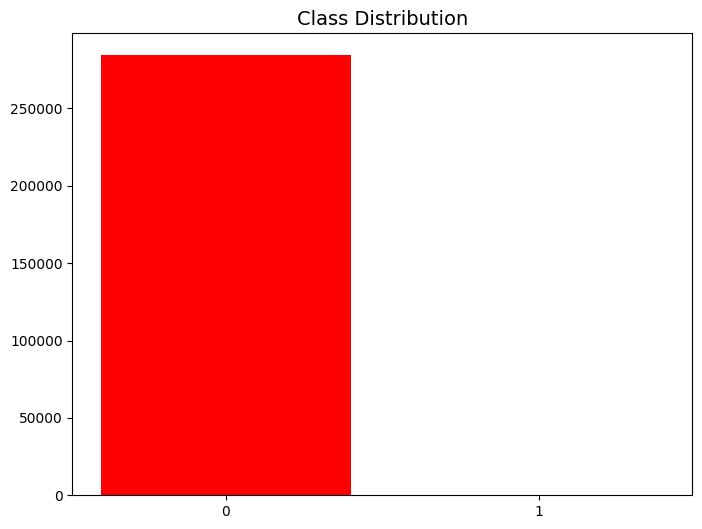

In [4]:
rcParams['figure.figsize'] = 8, 6
plt.bar(Credit['Class'].unique(), Credit['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.title("Class Distribution", fontsize=14)
plt.show()

In [5]:
x = Credit.drop('Class', axis=1)
y = Credit['Class']

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
Hp_params = {'criterion':['gini', 'entropy'], 'max_depth':[1,2,3,4,5,10,15,20]}
tree_GS_param = GridSearchCV(DecisionTreeClassifier(),  Hp_params, cv=5, scoring='roc_auc',n_jobs=-1, verbose=1)
tree_GS_param.fit(x_train, y_train)
print("The best parameters combined is ------")
print(tree_GS_param.best_params_)
print("The best score is ------")
print(tree_GS_param.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best parameters combined is ------
{'criterion': 'entropy', 'max_depth': 4}
The best score is ------
0.9395916013813908


In [8]:
y_pred = tree_GS_param.predict(x_test)

In [9]:
Conf_Matrix = confusion_matrix(y_test, y_pred)
print(Conf_Matrix)

Report = classification_report(y_test, y_pred, target_names=["Safe", "Fraud"])
print(Report)
 
#Calculate sensitivity and specificity
 
total=sum(sum(Conf_Matrix))

accuracy=(Conf_Matrix[0,0]+Conf_Matrix[1,1])/total
print ('Accuracy : ', accuracy)
 
sensitivity = Conf_Matrix[0,0]/(Conf_Matrix[0,0]+Conf_Matrix[0,1])
print('Sensitivity : ', sensitivity )
 
specificity = Conf_Matrix[1,1]/(Conf_Matrix[1,0]+Conf_Matrix[1,1])
print('Specificity : ', specificity)
 

[[56850    14]
 [   18    80]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994382219725431
Sensitivity :  0.9997537985368599
Specificity :  0.8163265306122449


In [10]:
%pip install graphviz 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install pydotplus

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz
import pydotplus
from IPython.display import Image

In [ ]:
#Error
#Dot_Credit = tree.export_graphviz(tree_GS_param.best_estimator_, feature_names=x.columns, class_names=["Good", "Fraud"], filled=True,rounded=True)
# =pydotplus.graph_from_dot_data(Dot_Credit)
#graph.write_png('Credit.png')
#Image(graph.create_png())

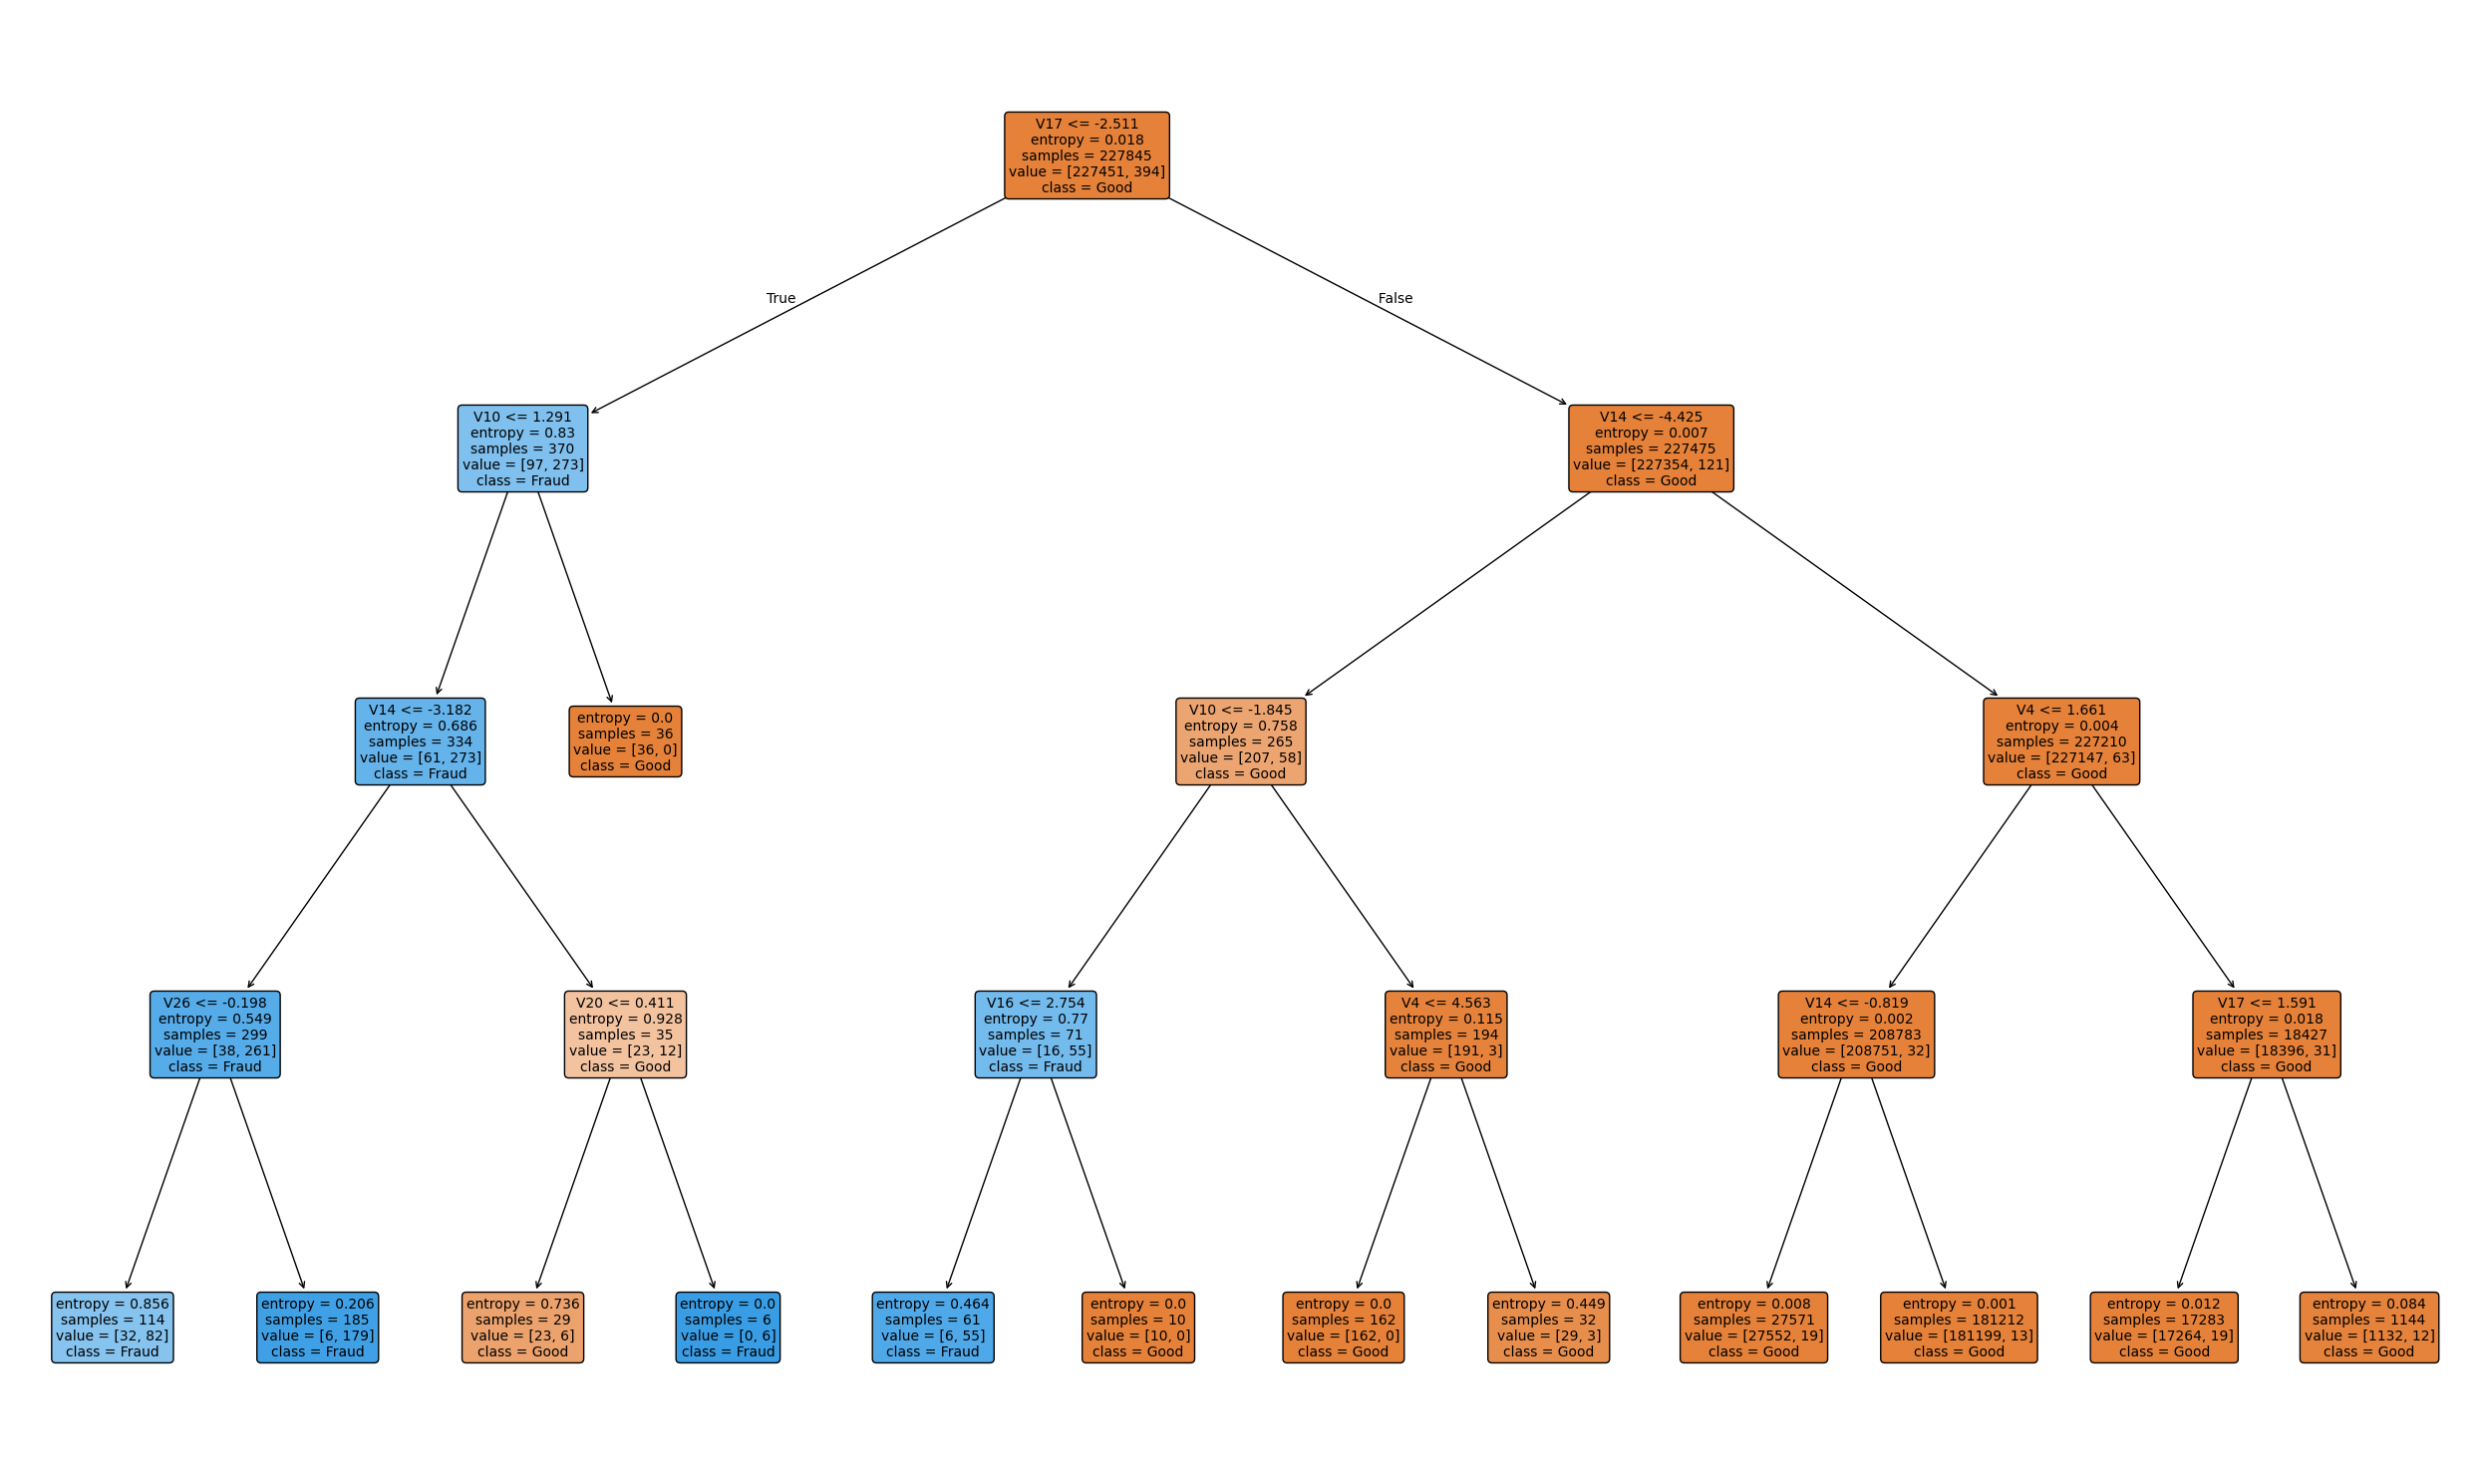

In [ ]:
#alternative way to visualize the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a large figure for better readability
plt.figure(figsize=(25, 15))

# Plot the decision tree
plot_tree(tree_GS_param.best_estimator_, 
          feature_names=x.columns.tolist(),
          class_names=["Good", "Fraud"],
          filled=True,
          rounded=True,
          fontsize=10)

plt.tight_layout()
plt.savefig('Credit.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.ensemble import BaggingClassifier
hp_bagging = {'n_estimators':[3,4,5,6]}
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
Best_Param = tree_bagg.best_params_
print ("The best paramter combination is: ", Best_Param)

Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best estimator is: ", Final_Model)

Best_AUS_score = tree_bagg.best_score_ #gets best score for best estimator
print("The best AUC score was: ", Best_AUS_score)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.9211089805859907


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
Hyper_paramters_RF={'criterion':['gini','entropy'],'max_depth':[4,10],'n_estimators':[50, 100], 'max_features':['sqrt'] }

Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)

#Print the best hyper paramters combination for the best model
Best_Param = tree_bagg.best_params_
print ("The best paramter combination is: ", Best_Param)

Final_Model = tree_bagg.best_estimator_ #gets best estimator
print("The best estimator is: ", Final_Model)

Best_AUS_score = tree_bagg.best_score_ #gets best score for best estimator
print("The best AUC score was: ", Best_AUS_score)  #gets best score for best estimator # -0.83828599184062269

Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.9185850115888853
